# Fundamentals of Diffusion via 2D Toy Data

Goal: develop an intuition for diffusion models by implementing DDPM training + DDPM/DDIM sampling from scratch on simple 2D distributions.

**Datasets**
- Circles, two-moons, and an Archimedean spiral (with small additive noise to avoid an infinitely thin manifold).

**Forward process**
- Cosine schedule to define $\beta_t$ and cumulative signal $\bar{\alpha_t}$.
- Efficient noising using the closed-form marginal: $x_t = \sqrt{\bar{\alpha_t}}x_{\theta} + \sqrt{(1-\bar{\alpha_t})} \epsilon$.

**Model + objective**
- Sinusoidal timestep embeddings.
- MLP denoiser predicting $\epsilon_{\theta}(x_t, t)$ trained with MSE($\epsilon_{\theta}, \epsilon$).
- Sample a different timestep t for each datapoint in the batch to cover many noise levels per minibatch.

**Sampling**
- DDPM: sample $x_{t-1} \sim N(\mu_{\theta}(x_t,t), \tilde{\beta_t}I)$ to generate points from pure Gaussian noise.
- DDIM: deterministic, timestep-skipping sampler for faster generation.
- Temperature sweep: scale reverse noise by $\gamma$ to study sharpness vs diversity and observe deterministic mode-seeking behavior at $\gamma \to 0$.

**Outputs**
- Qualitative plots showing forward noising progression and successful generation for circles/moons/spiral under DDPM/DDIM, plus $\gamma$-sweep visualizations.

# IMPORTS

In [2]:
import math
import torch
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt

In [3]:
print("Torch version: ", torch.__version__)

Torch version:  2.10.0+cu128


In [4]:
print("cuda available: ", torch.cuda.is_available())
if torch.cuda.is_available():
  print("cuda version: ", torch.cuda.get_device_name(0))

cuda available:  True
cuda version:  Tesla T4


# COSINE NOISE SCHEDULE

In [2](Section 3.2), they use a cosine noise scheduler instead of the original linear noise scheduler in [1].  
$\beta_t$ is the noise variance that is injected at timestep $t$.  
$\alpha_t = 1 - \beta_t$ is how much signal you keep at timestep $t$.  
$\bar{\alpha_t} = \Pi_{s=0}^T\alpha_s$ is how much of the original signal survives after $t$ timesteps. The reason why we use a product is because each $x$ depends on the previous one so the cumulative product tells us how much fraction is still present at a particular timestep.  
The interpretation is that if $\bar{\alpha_t} \approx 1$, then $x_t$ is very close to the original data and if $\bar{\alpha_t} \approx 0$, then $x_t$ is very close to pure noise.  
The closed-form forward distribution is:  
$x_t = \sqrt{\bar{\alpha_t}}x_0 + \sqrt{(1 - \bar{\alpha_t})}\epsilon$, $\epsilon \sim N(0, I)$  
A good schedule must not destroy the data early on so that the model has easy denoising problems to learn but it must still reach near-pure noise by the end so that sampling from random noise works. It must provide a smooth range of Signal-to-Noise Ratios (SNRs) so that the model learns denoising at many difficult levels.  
SNR is used to quantify how much of the original data is still present vs how much random Gaussian noise has taken over at a given timestep $t$.  
$SNR(t) = \frac{\bar{\alpha_t}}{1-\bar{\alpha_t}}$  
Cosine was proposed because it creates a more balanced SNR curve where there are lots of useful mid-range timesteps. Instead of guessing $\beta_t$ directly, cosine schedule chooses the shape of $\bar{\alpha_t}$ to follow a cosine curve and then derives $\beta_t$ from how $\bar{\alpha_t}$ changes between steps. Hence, $\bar{\alpha_t}$ controls the global SNR and cosine gives it a nice shape.  
Fraction of signal that survives from $t-1$ to $t$ is:  
$\alpha_t = \frac{\bar{\alpha_t}}{\bar{\alpha_t}-1}$  
Per-step noise is $\beta_t = 1 - \alpha_t$

Hence, the cosine schedule in terms of $\bar{\alpha_t}$ as described in [2] is:  
$\alpha_t = \frac{f(t)}{f(0)}$ where $f(t) =
cos(\frac{\frac{t}{T}+s}{1+s}\cdot \frac{\pi}{2})^2$  
$s$ is a small offset (they used $0.008$) that is used to prevent $\beta_t$ from being too small at $t=0$ since the researchers in [2] found out that having tiny amounts of noise at the beginning of the process made it hard for the network to predict $\epsilon$ accurately. $cos^2$ they mention it to be a design choice. They also say that they clip $\beta_t$ to $0.999$ to prevent singularities (mathematical weirdness like division by 0) at the end of the diffusion process at $t=T$.  
Here, I'm going to use $T=1000$.

In [5]:
T = 1000
s = 0.008
device = "cuda"

In [6]:
# u is a grid of T+1 points (0, 1, ..., T)
u = torch.arange(T+1, device=device).float()
print("u shape: ", u.shape)
print("u[0], u[-1]: ", u[0].item(), u[-1].item())

u shape:  torch.Size([1001])
u[0], u[-1]:  0.0 1000.0


In [7]:
def generate_alpha_bar_u(u, T=1000, s=0.008):
  x = (u/T + s)/(1 + s) # normalize u to [0,1] and apply offset s
  angles = x * ((math.pi)/2) # convert to angles going from approx. 0 to approx. pi/2
  f = torch.cos(angles) ** 2
  alpha_bar_u = f/f[0]

  return alpha_bar_u

alpha_bar_u = generate_alpha_bar_u(u)
print("alpha_bar_u[0], alpha_bar_u[-1]:", alpha_bar_u[0].item(), alpha_bar_u[-1].item())

alpha_bar_u[0], alpha_bar_u[-1]: 1.0 1.9109825619709545e-15


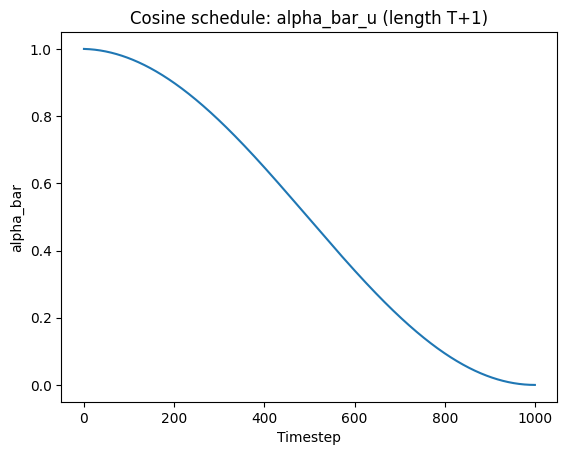

In [8]:
plt.figure()
plt.plot(alpha_bar_u.detach().cpu().numpy())
# detach to remove it from the computation graph as matplotlib cannot plot a tensor that is tracking gradients
# cpu to move tensor from gpu to cpu as matplotlib cannot read cuda tensors
# numpy to convert tensor to numpy array which matplotlib needs
plt.title("Cosine schedule: alpha_bar_u (length T+1)")
plt.xlabel("Timestep")
plt.ylabel("alpha_bar")
plt.show()

per-step noise is:  
$\beta_t = 1 - \frac{\bar{\alpha}_{t+1}}{\bar{\alpha_t}}$

In [9]:
betas = 1.0 - (alpha_bar_u[1:])/(alpha_bar_u[:-1]) # numerator is one timestep ahead
betas = torch.clamp(betas, 1e-5, 0.999)

alphas = 1 - betas
alpha_bar = torch.cumprod(alphas, dim=0)

print("betas_shape: ", betas.shape)
print("betas min/max: ", betas.min().item(), betas.max().item())
print("alpha_bar[0], alpha_bar[499], alpha_bar[-1]: ", alpha_bar[0].item(), alpha_bar[499].item(), alpha_bar[-1].item())

betas_shape:  torch.Size([1000])
betas min/max:  4.124641418457031e-05 0.9990000128746033
alpha_bar[0], alpha_bar[499], alpha_bar[-1]:  0.9999587535858154 0.49384382367134094 2.428147682920212e-09


# 2D DATASET GENERATOR

B is the batch size (how many 2D points that are sampled at once). So, $x_0$ will have shape (B,2).  
Noise is added to the toy data so that it is more realistic as real data has variability/thickness and it is easier and more stable to learn to avoid a super-sharp manifold (zoom in enough and it looks like flat space) distribution.

**Circles (noisy ring)**  
$\theta \sim Uniform(0, 2\pi)$  
$r = 1 + \sigma\zeta, \  \zeta \sim N(0,1)$
Here,  
$r$ is the radius of a sampled point on the circle,  
1 is the base radius,  
$\zeta$ is a random variable drawn from a standard normal distribution with mean $0$ and variance $1$,  
$\sigma$ is the standard deviation (scale) of how much you let the radius wobble  

Now, we can just do: $x = rcos\theta$ and $y = rsin\theta$ (polar coordinates)

In [ ]:
def sample_circle(B, noise=0.05, device=device):
  theta = 2*math.pi*torch.rand(B, device=device)
  r = 1.0 + noise*torch.randn(B, device=device)
  x = r * torch.cos(theta)
  y = r * torch.sin(theta)

  return torch.stack([x, y], dim=1)

**Moons (two semicircles offset)**  
Make two half-circles (each with $\theta \in [0, \pi]$).  
Upper moon:  
$(x1, y1) = (cos\theta, \ sin\theta), \ \theta \sim Uniform(0, \pi)$  
Lower moon (shifted and flipped):  
$(x2, y2) = (1 - cos\theta, \ -sin\theta - 0.5), \ \theta \sim Uniform(0, \pi)$  
Add noise:  
$(x, y) = (x, y) + \sigma\epsilon, \ \epsilon \sim N(0, I_2)$

In [11]:
def sample_moons(B, noise=0.05, device=device):
  B1 = B//2
  B2 = B - B1

  t1 = math.pi * torch.rand(B1, device=device)
  x1 = torch.cos(t1)
  y1 = torch.sin(t1)

  t2 = math.pi * torch.rand(B2, device=device)
  x2 = 1.0 - torch.cos(t2)
  y2 = - torch.sin(t2) - 0.5

  x = torch.cat([x1, x2], dim=0)
  y = torch.cat([y1, y2], dim=0)

  pts = torch.stack([x, y], dim=1)
  pts = pts + noise * torch.randn_like(pts)

  return pts

**Spiral (Archimedean spiral)**  
Parameterize a spiral by an angle $t$, with radius proportional to $t$.  
Let $u \sim Uniform(0, 1).$  
Let $t = t_{max}\sqrt{u}$ where $t_{max} = 4\pi$ would be the number of turns in the spiral and $\sqrt{u}$ helps avoid over-concentrating points near the center.  
Let $r = \frac{t}{t_{max}}$ so $r \in [0, 1].$  
Then:  
$x = rcos(t)$ and $y = rsin(t)$  

In [12]:
def sample_spiral(B, noise=0.02, device=device, t_max=8*math.pi):
  u = torch.rand(B, device=device)
  t = t_max * torch.sqrt(u)
  r = t / t_max
  x = r * torch.cos(t)
  y = r * torch.sin(t)
  pts = torch.stack([x, y], dim=1)
  pts = pts + noise * torch.randn_like(pts)

  return pts

**Visualize**

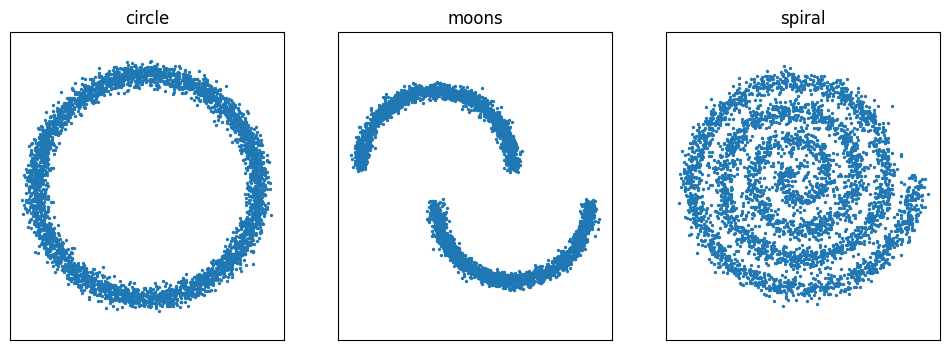

In [ ]:
B = 4096
samplers = {
    "circle": sample_circle,
    "moons": sample_moons,
    "spiral": sample_spiral
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4)) # 1x3 grid of plots
for ax, (name, fn) in  zip(axes, samplers.items()):
  # samplers.items() gives pairs: (name, fn)
  # zip(axes, samplers.items()) pairs first subplot axis with "circles", sample_circle and so on
  x0 = fn(B, noise=0.05, device=device).detach().cpu()
  ax.scatter(x0[:, 0], x0[:, 1], s=2)
  # scatter-plots points first param is all x-coords, second param is all y-coords, s=2 makes points tiny so it looks like a clean cloud
  ax.set_title(name)
  ax.axis("equal")
  # forces equal scaling on x and y axes so that circles don't look like ovals
  ax.set_xticks([])
  ax.set_yticks([])
  # removes tick marks/labels to make plot cleaner
plt.show()

# FORWARD DIFFUSION
generate q_sample

$x_t = \sqrt{\bar{\alpha_t}}x_0 + \sqrt(1-\bar{\alpha_t})\epsilon, \epsilon \sim N(0, I)$

In [14]:
def generate_q_sample(x0, t, eps, alpha_bar):
  alpha_bar_t = alpha_bar[t].unsqueeze(1)
  # alpha_bar_t has shape (B, ) = 1D tensor with one value per batch element
  # x0 has shape (B, 2)
  # A shape (B, ) tensor cannot multiply a shape (B, 2) tensor but a (B, 1) can for which we use the unsqueeze operation
  # unsqueeze(1) converts (B, ) to (B, 1)
  xt = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1.0 - alpha_bar_t) * eps
  # * is element-wise multiplication with broadcasting not matrix multiplication
  # broadcasting automatically expands the size 1 dimension to match size D
  # example:
  # [[0.9],      [[x1, x2, x3],         [[0.9*x1, 0.9*x2, 0.9*x3],
  #  [0.7],   *   [x4, x5, x6],    ->    [0.7*x4, 0.7*x5, 0.7*x6],
  #  [0.5]]       [x7, x8, x9]]          [0.5*x7, 0.5*x8, 0.5*x9]]
  # Broadcasting rule = dimensions must either be equal or one of the dimensions must be 1
  return xt

**Plots**

In [ ]:
B = 4096
timesteps = [0, 99, 499, 999]
samplers = {
    "circle": sample_circle,
    "moons": sample_moons,
    "spiral": sample_spiral
}

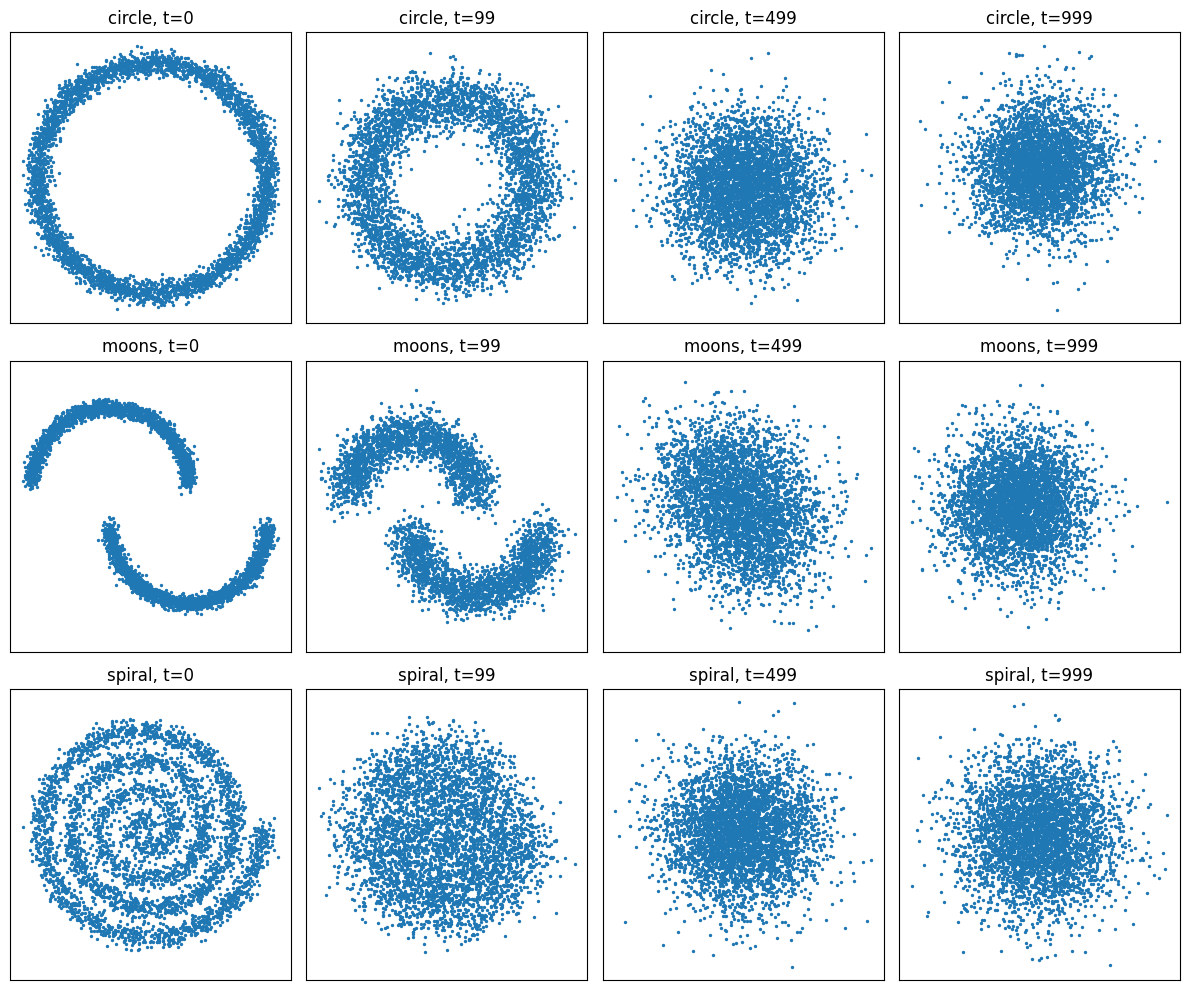

In [16]:
fig, axes = plt.subplots(len(samplers), len(timesteps), figsize=(12, 10))
for row, (name, fn) in enumerate(samplers.items()):
  x0 = fn(B, noise=0.05, device=device)
  for col, tv in enumerate(timesteps):
    t = torch.full((B,), tv, device=device, dtype=torch.long)
    # makes a vector of size B filled with timestep value tv
    eps = torch.randn_like(x0)
    xt = generate_q_sample(x0, t, eps, alpha_bar).detach().cpu()
    # in generate_q_sample, alpha_bar[t] might be a bit non-intuitive to understand
    # since t is a tensor of integers, PyTorch interprets it as:
    # "For each element t[i], pick alpha_bar[t[i]]"
    # So, it becomes a lookup table
    ax = axes[row, col]
    ax.scatter(xt[:,0], xt[:,1], s=2)
    ax.set_title(f"{name}, t={tv}")
    ax.axis("equal")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

# SINUSOIDAL TIME EMBEDDINGS

Model gets inputs $(x_t, t)$. If we only feed $x_t$ and ignore $t$, the network has no way to know how noisy the input is. But $t$ is just an integer say like $123$. Neural networks don't understand naturally that $123$ is closer to $124$ but further away from $999$ unless we encode it in a useful numeric form. Why would we need to encode it? Because neural networks work best when inputs are vectors of reasonable magnitude with rich distributed representations instead of a single number in which case the network has to pack all meaning into one dimension. So, we need to turn a single number into a meaningful vector. Some possibilities:
- One hot encoding  
If there are $T=1000$ timesteps, we could make a 1000-dimensional vector with a $1$ at position $T$. However, the problem is that there is huge dimensionality and there is no notion that $t=3$ and $t=4$ are close (their vectors are orthogonal) and it doesn't generalize to unseen timesteps.  
- Normalize the scalar  
Just feed $t/T$ values ranging from $0$ to $1$ but once again the network only gets one number and the network has to learn the complexity of what the noise level means from a single dimension.  
- Learned embedding table  
```
embed = nn.Embedding(1000, 128)  
t_vec = embed(t)  
```
This works and is used in some places but it requires parameters and only works for the allocated integer timesteps.






With all these limitations, we use sinusoidal embeddings. The idea is that by using different frequencies we can "measure" the number at a different resolution. Together, many frequencies give a unique fingerprint for every number.  
**Building up**  
**Using just one frequency**  
```
omega = 0.1
t = torch.arange(1000)
embed = torch.sin(t * omega) # shape (1000, ) - one value per timestep
```
This maps each timestep to a point on a sine wave but sine is periodic so many different $t$ values map to the same output leading to ambiguity.  
**Add cosine to remove ambiguity within a cycle**  
```
embed = torch.stack([torch.sin(t*omega), torch.cos(t*omega)], dim=1) #(1000, 2)
```
Now each $t$ maps to a (sin, cos) pair. Within one full period every $t$ gets a unique 2D point but if the period is short, $t$ values far apart can still collide.  
**Add more frequencies to remove all ambiguity**  
```
omegas = [1.0, 0.1, 0.01, 0.001] #fast to slow
embeds = []
for omega in omegas:
  embeds.append(torch.sin(t * omega))
  embeds.append(torch.cos(t * omega))
embed = torch.stack(embeds, dim=1) # (1000, 8)
```
Now there are $8$ dimensions. The fast frequency distinguishes the nearby timesteps and the slow one distinguishes distant ones. The chance of two different timesteps having the same $8D$ vector is essentially zero.

The standard formula as used in [3] just systematizes this where instead of choosing frequencies by hand it spaces them logarithmically:  
$\omega_k = \frac{1}{10000^{\frac{2k}{d}}}$  
$d$ is the embedding dimension, typically chosen as $128$ or $256$.  
$k$ is the index that counts through each frequency band, from $0$ to $\frac{d}{2}-1$.  
Since each frequency band produces two values: a sin and a cos, if we went all the way to $k=d$ we'd have $d$ frequency bands giving $2$ values each giving us $2d$ dimensions which is twice as large as we want.  
$10000$ is a convention from [3].  
We need log-spaced since we want features that vary at many scales where some change slowly with $t$ (small frequency) and some change quickly (large frequency). Since we multiply timestep with frequency, if we use small $\omega$ only, nearby timesteps look almost identical and if we use large $\omega$ only we lose stable global structure so we need a mix of both. Log spacing ensures that each next frequency differs by a constant ratio so we cover the range evenly across scales.

This is used in diffusion because denoising behavior changes smoothly but nonlinearly with time. Sinusoidal embeddings give the network a clean way to represent this conditioning.

In [17]:
def time_embedding(t: torch.Tensor, dim: int = 128) -> torch.Tensor:
  t = t.view(-1).float()
  #.view(-1) flattens the vector into a 1D vector so we get vector of shape (B, ) with type float
  half = dim // 2
  freqs = torch.exp(-math.log(10000)*(torch.arange(0, half, device=t.device).float()/max(half-1, 1)))
  # torch.arange(0, half, device=t.device).float() creates [0, 1, 2, ..., half-1] so the shape is (half,)
  # dividing by max(half-1, 1) normalizes the indices into the range [0,1]: k/(half-1) would lie in [0,1]. There will now be a smooth progression from 0 to 1.
  # exp(log(a)*c) = exp(log(a^c)) = a^c
  args = t[:, None] * freqs[None, :]
  # t is (B,), t[:, None] makes it (B, 1) (adds a column dimension)
  # freqs is (half,), freqs[None, :] makes it (1, half) (adds a row dimension)
  # (B, 1) * (1, half) broadcasts to (B, half)
  # args_{i,k} = t_i\cdot \omega_k
  emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
  # rule of thumb for concatenation along dim=k is that all other dimensions must match
  # dim=0 is like gluing rows together, so this leads to more examples
  # dim=1 is like gluing columns together, so this is done when we want more features

  if dim%2==1:
    emb = torch.cat([emb, torch.zeros(emb.shape[0], 1, device=t.device)], dim=1)

  return emb # (B, dim)

In [18]:
B = 4
T = 1000
t_test = torch.tensor([0, 1, 500, 999], device=device, dtype=torch.long)
emb = time_embedding(t_test, dim=128)

print("t_test:", t_test)
print("emb shape:", emb.shape)
print("range:", emb.min().item(), emb.max().item()) # within [-1, 1]

t_test: tensor([  0,   1, 500, 999], device='cuda:0')
emb shape: torch.Size([4, 128])
range: -0.9996814131736755 1.0


# $\epsilon$-MLP

We ultimately want a model that can generate samples (circles/moons/spirals) by starting from pure Gaussian noise and denoising step-by-step. To denoise from $x_t$ to $x_{t-1}$, the algorithm needs some estimate of what part of $x_t$ is noise. So, we train a neural net to do this:
$$\epsilon_{\theta}(x_t, t) \approx \epsilon$$
where $\epsilon$ is the random Gaussian noise that was used to create $x_t$ from a clean sample $x_0$. Once we can predict $\epsilon$, we can compute an estimate of $x_0$ and step backwards in time.  
From forward diffusion:
$$x_t = \sqrt{\bar{\alpha_t}}x_0 + \sqrt{(1-\bar{\alpha_t})}\epsilon$$
Rearranging gives us:
$$x_0 = \frac{x_t - \sqrt{(1-\bar{\alpha_t})}\epsilon}{\sqrt{\bar{\alpha_t}}}$$
So, if the network gives $\widehat{\epsilon}$, we can plug it in and get $\widehat{x_0}$ which is the core denoise operation. In the formula above, the schedule $\bar{\alpha_t}$ tells how much signal/noise scaling is present and the network must infer the direction/patters of the noise $\epsilon$.  
The network needs both $x_t$ and $t$ because the correct denoising behavior depends heavily on how noisy $x_t$ is which depends on $t$ where for small $t$, $x_t$ is almost clean and hence only needs a tiny correction whereas for large $t \approx 999$, $x_t$ is almost pure noise so it needs a huge correction which is mostly guided by learned structure (what the model learned about the data distribution). Hence, we embed $t$ and feed it to the network.  
For this toy setting, data is $2D$: $x_t \in \mathbb{R}^2$ and timestep embedding is $128D$: $emb(t) \in \mathbb{R}^{128}.$ So, each example is a vector in $\mathbb{R}^{130}$ ($2$ coords and $128$ time features) and we need a function $f_{\theta}: \mathbb{R}^{130} \to \mathbb{R}^{2}$ that maps noisy point + time context to noise vector to remove.  
An MLP is the simplest universal function approximator for this. The mapping is nonlinear because:  
- at different $t$, the function changes
- the dataset structure (moons, spiral) is nonlinear
- the network must learn how the data manifold looks (the geometric shape/pattern where valid data points tend to lie in space, it is important because learning the underlying shape of the data distribution helps to steer noisy points back to it during reverse diffusion) and how noise perturbs it.

A few hidden layers gives the network enough capacity to represent that function.

The choice of activation function is **SiLU** (called swish). It is a smooth nonlinear activation function commonly used in diffusion because:  
- it is smooth (good for modeling smooth denoising fields)
- it trains stably compared to some sharper activations   

For an input $x$, SiLU is:
$$SiLU(x) = x\cdot \sigma(x)$$
where $\sigma(x) = \frac{1}{1+e^{-x}}$ is the sigmoid. So, it multiplies the input by a soft gate between $0$ and $1$. The intuition is that for a large positive $x$, SilU passes it through and for a large negative $x$, SiLU suppresses it and around $0$ it is smooth and gradually transitions. Nonlinearity is necessary so the model can learn the complex curved mapping from $(x_t, t) \to $ noise direction.  
For images, $x_t$ is huge ($64 \times 64 \times 3$) and spatial structure matters so we use U-nets but here, $x_t$ is just $2$ numbers and MLP is much easier to apply in this case.

In [19]:
D = 128 # time embedding dim

class EpsMLP(nn.Module):
  def __init__(self, time_dim=D, hidden=256, depth=4):
    super().__init__()
    self.time_dim = time_dim
    self.hidden_dim = hidden
    input_dim = 2 + time_dim
    output_dim = 2
    layers = []
    layers.append(nn.Linear(input_dim, hidden))
    layers.append(nn.SiLU())
    # first layer

    for _ in range(depth-1):
      layers.append(nn.Linear(hidden, hidden))
      layers.append(nn.SiLU())
    # d-1 hidden layers

    layers.append(nn.Linear(hidden, output_dim))
    # output layer (no activation)

    self.net = nn.Sequential(*layers)

  def forward(self, x_t, t):
    time_embs = time_embedding(t, self.time_dim) # (B, time_dim)
    h = torch.cat([x_t, time_embs], dim=1) # (B, 2+time_dim)
    return self.net(h) # (B, 2)

In [20]:
B_test = 8
x_test = torch.randn(B_test, 2, device=device)
t_test = torch.randint(0, T, (B_test,), device=device, dtype=torch.long)

model = EpsMLP(time_dim=128, hidden=256, depth=4).to(device)
out = model(x_test, t_test)

print("out shape:", out.shape)
print("finite:", torch.isfinite(out).all().item()) # prints True only if all values of the tensor are finite

out shape: torch.Size([8, 2])
finite: True


# Training

During training, we know $x_0$ from the dataset, so it is possible to compute $x_t$ and recover the noise that was used for that training example. But during generation (sampling), we do not know $x_0$. In fact, there is no $x_0$ yet and we are trying to create one. During sampling, we start from pure Gaussian noise and we go backward but at $x_T$ time, we neither have $x_0$ nor do we know which noise realization produced the $x_T$. So, we train a neural network to learn a function that tell us "Given a noisy point $x_t$ at noise level $t$, what is the most likely noise component (or what is the score/denoising direction) under the data distribution?". This is the learned prior / learned structure which lets us move from random noise toward points that look like the dataset.  

In each minibatch of size $B$, the timestep value can be different for every datapoint. So each training step contains examples from many noise levels at once which is efficient and standard for diffusion. We could also use a single value for the whole batch and learning would still be possible but we'd cover noise levels much more slowly.

In [ ]:
samplers = {
    "circle": sample_circle,
    "moons": sample_moons,
    "spiral": sample_spiral
}
dataset_name = "circle"
sampler = samplers[dataset_name]

B = 2048
lr = 2e-4

model = model.to(device)
model.train()

opt = Adam(model.parameters(), lr=lr)
mse = nn.MSELoss()

x0 = sampler(B, noise=0.05, device=device) #(B, 2)
t = torch.randint(0, T, (B,), device=device, dtype=torch.long) # (B,)

eps = torch.randn_like(x0)
xt = generate_q_sample(x0, t, eps, alpha_bar)

eps_hat = model(xt, t)
loss = mse(eps_hat, eps)

opt.zero_grad() # clears accumulated gradients
loss.backward() # runs backpropagation
opt.step() # updates the model parameters

print("loss:", loss.item())
print("x0/xt/eps_hat shapes:", x0.shape, xt.shape, eps_hat.shape)
print("t dtype/device:", t.dtype, t.device)

loss: 0.9882327318191528
x0/xt/eps_hat shapes: torch.Size([2048, 2]) torch.Size([2048, 2]) torch.Size([2048, 2])
t dtype/device: torch.int64 cuda:0


step   500 | avg loss 0.4616
step  1000 | avg loss 0.4104
step  1500 | avg loss 0.4096
step  2000 | avg loss 0.4087
step  2500 | avg loss 0.4077
step  3000 | avg loss 0.4015
step  3500 | avg loss 0.3413
step  4000 | avg loss 0.3255
step  4500 | avg loss 0.3233
step  5000 | avg loss 0.3233


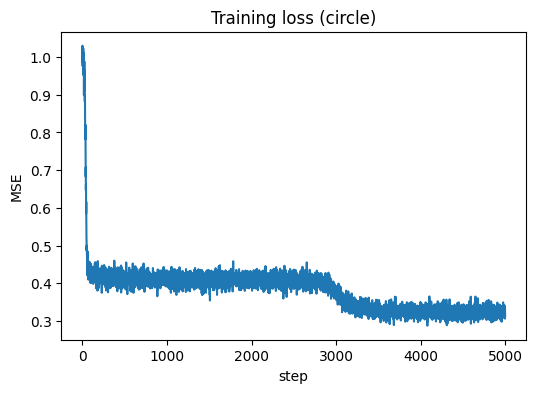

In [ ]:
samplers = {
    "circle": sample_circle,
    "moons": sample_moons,
    "spiral": sample_spiral
}
dataset_name = "circle"
sampler = samplers[dataset_name]

B = 2048
lr = 2e-4

model = model.to(device)
model.train()
# sets pytorch MLP model to training mode
# doesn't do anything here but it is a good habit

opt = Adam(model.parameters(), lr=lr)
mse = nn.MSELoss()

num_steps = 5000
print_every = 500

losses = []

for step in range(1, num_steps+1):
  x0 = sampler(B, noise=0.05, device=device) # (B, 2)
  t = torch.randint(0, T, (B,), device=device, dtype=torch.long)
  # different timestep for each example in batch
  eps = torch.randn_like(x0)

  xt = generate_q_sample(x0, t, eps, alpha_bar)

  eps_hat = model(xt, t)
  loss = mse(eps_hat, eps)

  opt.zero_grad() # clears the accumulated gradients otherwise new ones get added to old ones
  loss.backward() # runs backpropagation
  opt.step() # updates the model parameters

  losses.append(loss.item())

  if step % print_every == 0:
    avg = sum(losses[-print_every:]) / print_every
    print(f"step {step:5d} | avg loss {avg:.4f}")

plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title(f"Training loss ({dataset_name})")
plt.xlabel("step")
plt.ylabel("MSE")
plt.show()

step   500 | avg loss 0.5024
step  1000 | avg loss 0.4498
step  1500 | avg loss 0.4475
step  2000 | avg loss 0.4261
step  2500 | avg loss 0.3991
step  3000 | avg loss 0.3683
step  3500 | avg loss 0.3536
step  4000 | avg loss 0.3460
step  4500 | avg loss 0.3442
step  5000 | avg loss 0.3412


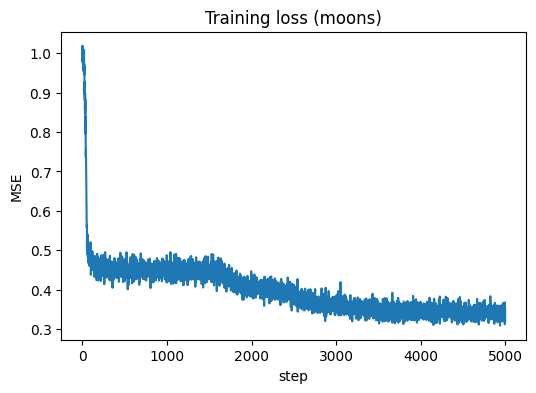

In [ ]:
samplers = {
    "circle": sample_circle,
    "moons": sample_moons,
    "spiral": sample_spiral
}
dataset_name = "moons"
sampler = samplers[dataset_name]

B = 2048
lr = 2e-4

model2 = EpsMLP(time_dim=128, hidden=256, depth=4).to(device)
model2 = model2.to(device)
model2.train()
# sets pytorch MLP model to training mode
# doesn't do anything here but it is a good habit

opt = Adam(model2.parameters(), lr=lr)
mse = nn.MSELoss()

num_steps = 5000
print_every = 500

losses = []

for step in range(1, num_steps+1):
  x0 = sampler(B, noise=0.05, device=device) # (B, 2)
  t = torch.randint(0, T, (B,), device=device, dtype=torch.long)
  # different timestep for each example in batch
  eps = torch.randn_like(x0)

  xt = generate_q_sample(x0, t, eps, alpha_bar)

  eps_hat = model2(xt, t)
  loss = mse(eps_hat, eps)

  opt.zero_grad() # clears the accumulated gradients otherwise new ones get added to old ones
  loss.backward() # runs backpropagation
  opt.step() # updates the model parameters

  losses.append(loss.item())

  if step % print_every == 0:
    avg = sum(losses[-print_every:]) / print_every
    print(f"step {step:5d} | avg loss {avg:.4f}")

plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title(f"Training loss ({dataset_name})")
plt.xlabel("step")
plt.ylabel("MSE")
plt.show()

step  5000 | avg loss 0.3336
step 10000 | avg loss 0.3196
step 15000 | avg loss 0.3119
step 20000 | avg loss 0.3104
step 25000 | avg loss 0.3094
step 30000 | avg loss 0.3089
step 35000 | avg loss 0.3082
step 40000 | avg loss 0.3076
step 45000 | avg loss 0.3068
step 50000 | avg loss 0.3060
step 55000 | avg loss 0.3059
step 60000 | avg loss 0.3052
step 65000 | avg loss 0.3052
step 70000 | avg loss 0.3048
step 75000 | avg loss 0.3046


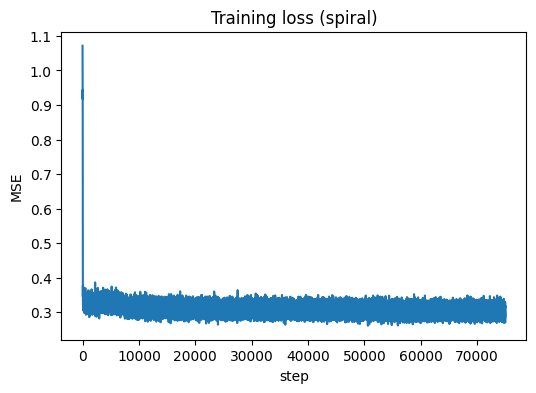

In [ ]:
samplers = {
    "circle": sample_circle,
    "moons": sample_moons,
    "spiral": sample_spiral
}
dataset_name = "spiral"
sampler = samplers[dataset_name]

B = 2048
lr = 2e-4

model3 = EpsMLP(time_dim=128, hidden=256, depth=4).to(device)
model3 = model3.to(device)
model3.train()
# sets pytorch MLP model to training mode
# doesn't do anything here but it is a good habit

opt = Adam(model3.parameters(), lr=lr)
mse = nn.MSELoss()

num_steps = 75000
print_every = 5000

losses = []

for step in range(1, num_steps+1):
  x0 = sampler(B, noise=0.02, device=device) # (B, 2)
  t = torch.randint(0, T, (B,), device=device, dtype=torch.long)
  # different timestep for each example in batch
  eps = torch.randn_like(x0)

  xt = generate_q_sample(x0, t, eps, alpha_bar)

  eps_hat = model3(xt, t)
  loss = mse(eps_hat, eps)

  opt.zero_grad() # clears the accumulated gradients otherwise new ones get added to old ones
  loss.backward() # runs backpropagation
  opt.step() # updates the model parameters

  losses.append(loss.item())

  if step % print_every == 0:
    avg = sum(losses[-print_every:]) / print_every
    print(f"step {step:5d} | avg loss {avg:.4f}")

plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title(f"Training loss ({dataset_name})")
plt.xlabel("step")
plt.ylabel("MSE")
plt.show()

# REVERSE PROCESS (SAMPLING)

At training time, we learn a function which given a noisy point $x_t$ and a timestep $t$ predicts the noise direction/pattern. To go backwards, we use the known schedule scalars $\alpha_t, \beta_t, \bar{\alpha_t}$ to compute the reverse Gaussian:  
$$p_{\theta}(x_{t-1} | x_t) = N(\mu_{\theta}(x_t, t), \sigma_t^2I)$$
$$x_{t-1} = \mu_{\theta}(x_t, t) + \sigma_tz, z \sim N(0, I)$$
The reason DDPM (denoising diffusion probabilistic model) is written this way is because the true reverse process is stochastic and not deterministic and that stochasticity matters for matching the data distribution.

Knowing the noise direction doesn't uniquely determine $x_{t-1}$. In the forward process, $\epsilon \sim N(0, I)$ so given $x_t$ there are many possible $x_{t-1}$ that could have lead to it depending on the random $\epsilon$. So, the inverse is not one-to-one. Hence, the correct mathematical object is a conditional distribution $q(x_{t-1} | x_t)$ not a single point. Since the forward steps are Gaussian, the reverse posterior is also a Gaussian.

$\mu_{\theta}$ is the model's best guess of the mean of $x_{t-1}$ given $x_t$. We can think of it like $\epsilon_{\theta}$ gives a denoising direction and $\mu_{\theta}$ converts that into a predicted center point for $x_{t-1}$. $z$ is the fresh random noise we draw during sampling time (different from the $\epsilon$ used in the forward corruption). $\sigma_tz$ injects stochasticity so that we get diversity so that even if two trajectories have similar $x_t$, the random $z$ can lead to different valid outcomes. Also, the true reverse process is not a single path but rather a distribution over possible $x_{t-1}$ given $x_t$. Sampling noise helps approximate that. We can also avoid collapse to the most likely paths which would happen if we just use $x_{t-1} = \mu_{\theta}$ (no noise). Hence, $\sigma_tz$ provides the randomness needed to explore different valid samples while still staying data-like.  

The standard form that is generally used is:  
$$\mu_{\theta}(x_t, t) = \frac{1}{\sqrt{\alpha_t}}\big (x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha_t}}}\epsilon_{\theta}(x_t, t) \big )$$

The posterior variance is written as:
$$\tilde{\beta_t} = \beta_t \cdot \frac{1-\bar{\alpha_{t-1}}}{1-\bar{\alpha_t}}$$

Then we can sample as:
- if $t>0: x_{t-1} = \mu_{\theta} + \sqrt{\tilde{\beta_t}}z, z \sim N(0, I)$
- if $t=0: return \ \mu_{\theta}$ (no noise at final step)

In [25]:
alphas = 1 - betas
alpha_bar_prev = torch.cat([torch.ones(1, device=device), alpha_bar[:-1]], dim=0)
# alpha_bar_prev[t] = alpha_bar[t-1] with alpha_bar_prev[0] = 1

posterior_var = betas * (1.0 - alpha_bar_prev)/(1.0 - alpha_bar) # posterior variance beta_tilde
posterior_var = torch.clamp(posterior_var, min=1e-20) # safety

In [26]:
@torch.no_grad()
def per_step_sample_ddpm(model, xt, t):
  B = xt.shape[0]
  t_int = t
  t = torch.full((B,), t, device=device, dtype=torch.long)
  eps_hat = model(xt, t)

  beta_t = betas[t].unsqueeze(1) # (B, 1)
  alpha_t = alphas[t].unsqueeze(1) # (B, 1)
  alpha_bar_t = alpha_bar[t].unsqueeze(1) # (B, 1)

  mu = (xt - (beta_t /torch.sqrt(1.0 - alpha_bar_t))* eps_hat)/(torch.sqrt(alpha_t)) # mean

  if t_int==0:
    return mu

  z = torch.randn_like(xt)
  sigma = torch.sqrt(posterior_var[t].unsqueeze(1))

  return mu + sigma * z # sample with posterior variance

@torch.no_grad()
def sample_ddpm(model, n=5000):
  # n = how many points i want to generate from the model, for visualization purposes
  model.eval()
  x = torch.randn(n, 2, device=device) # start from pure noise
  for t in reversed(range(T)):
    x = per_step_sample_ddpm(model, x, t)

  return x

def plot_samples(x, title="samples"):
  x = x.detach().cpu()
  plt.figure(figsize=(4,4))
  plt.scatter(x[:, 0], x[:, 1], s=2)
  plt.axis("equal")
  plt.title(title)
  plt.xticks([])
  plt.yticks([])
  plt.show()

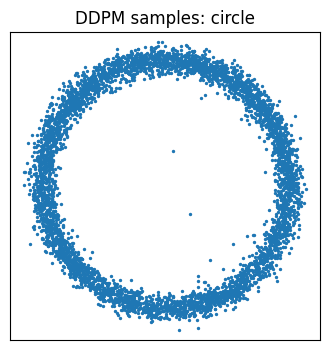

In [27]:
# circle
plot_samples(sample_ddpm(model), "DDPM samples: circle")

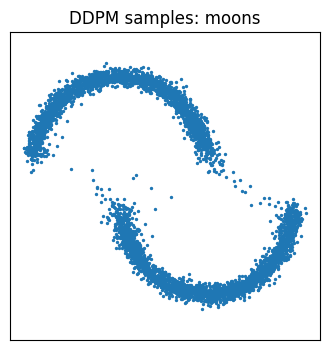

In [28]:
# moons
plot_samples(sample_ddpm(model2), "DDPM samples: moons")

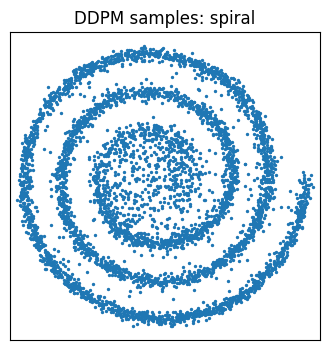

In [29]:
# spiral
plot_samples(sample_ddpm(model3), "DDPM samples: spiral")

# DETERMINISTIC DDIM

DDPM sampling is stochastic as it adds fresh noise every step and it uses all $T$ steps. However, the authors of [4] proposed "Denoising Diffusion Implicit Models" (DDIM) where they use an alternative reverse-time process that uses the same trained model and produces samples with the same marginals (same "distribution at time 0") but can be made deterministic and can skip timesteps.  

Note on **"same marginals"**:  
If you have a process that produces samples through many intermediate steps, the marginal at time $0$ is just the distribution of $x_0$ by itself, ignoring all the intermediate steps that got you there. DDPM takes a random winding path with large number of small random steps whereas DDIM takes a straight deterministic path with a small number of large steps. Even though both of them take different paths, they end up at the same final distribution. This matters because, the DDPM training objective only constrains what the marginal distributions at each timestep should be. It doesn't uniquely determine the path between timesteps. DDIM exploits this by finding a different deterministic path that still arrives at the correct final distribution using the exact same trained noise predictor. This is why it is called "implicit". We are not explicitly sampling from the DDPM reverse Gaussian every step but a different, usually non-Markov update rule that is consistent with the diffusion marginals.   

General forward closed form:  
$$x_t = \sqrt{\bar{\alpha_t}}x_0 + \sqrt{1-\bar{\alpha_t}\epsilon}, \epsilon \sim N(0, I)$$  

Network predicts $\widehat{\epsilon} = \epsilon_{\theta}(x_t, t)$ using which we can estimate the clean sample by rearranging the equation above:
$$\widehat{x_0}(x_t, t) = \frac{x_t - \sqrt{(1 - \bar{\alpha_t})}\widehat{\epsilon}}{\sqrt{\bar{\alpha_t}}}$$  

DDIM uses $\widehat{x_0}$ and $\widehat{\epsilon}$ to jump from timestep $t$ to an earlier timestep $s<t$ to re-synthesize a less noisy point.  

**Deterministic DDIM**  
$$x_s = \sqrt{\bar{\alpha_s}}\widehat{x_0} + \sqrt{(1 - \bar{\alpha_s})\widehat{\epsilon}}$$
Since there is no random noise, given the same starting noise $x_T$, you get the same output every time.

**Note:**  
We apply a clipping hack on $\widehat{x_0}$ to prevent amplification of $\frac{1}{\sqrt{\bar{\alpha_t}}}$. When t is large, $\bar{\alpha_t}$ is tiny. When re-synthesizing a less noisy sample, small prediction errors in $\widehat{\epsilon}$ can get magnified a lot causing $\widehat{x_0}$ to become huge and the next step uses that huge $\widehat{x_0}$ and the error snowballs. By clipping, we prevent extreme $\widehat{x_0}$ values from dominating the update and stabilize the deterministic trajectory. This is not a part of the pure math derivation but it is a common practical stabilization.  

A simple way to choose clip value is to look at the ranges of the training data and then set clamp bounds a bit wider than that (2-3x).

In [30]:
@torch.no_grad()
def sample_ddim_deterministic(model, n=5000, steps=50):
  model.eval()
  x = torch.randn(n, 2, device=device)
  ts = torch.linspace(T-1, 0, steps, device=device).long()
  # T-1 because timesteps are 0-indexed (0 to 999)
  # alpha_bar[1000] is out of bounds

  for i in range(len(ts) - 1):
    t = ts[i].item()
    s = ts[i+1].item()

    t_batch = torch.full((n,), t, device=device, dtype=torch.long)
    s_batch = torch.full((n,), s, device=device, dtype=torch.long)

    eps_hat = model(x, t_batch) # (n,2)
    alpha_bar_t = alpha_bar[t_batch].unsqueeze(1)

    x0_hat = (x - ((torch.sqrt(1.0 - alpha_bar_t))*eps_hat))/(torch.sqrt(alpha_bar_t))
    x0_hat = torch.clamp(x0_hat, -2.0, 2.0)
    # clipping hack
    alpha_bar_s = alpha_bar[s_batch].unsqueeze(1)

    x = (torch.sqrt(alpha_bar_s) * x0_hat) + (torch.sqrt(1.0 - alpha_bar_s) * eps_hat)

  return x

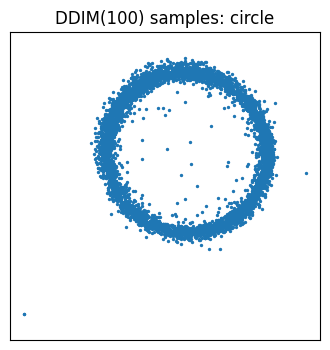

In [31]:
# circle
plot_samples(sample_ddim_deterministic(model, steps=100), "DDIM(100) samples: circle")

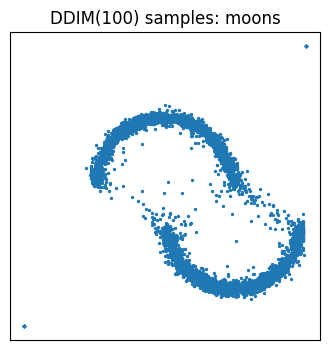

In [32]:
# moons
plot_samples(sample_ddim_deterministic(model2, steps=100), "DDIM(100) samples: moons")

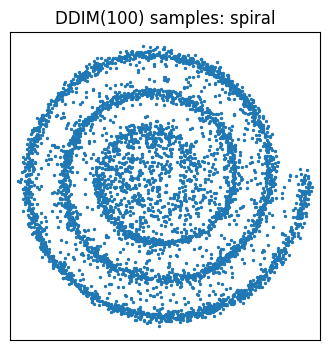

In [33]:
# spiral
plot_samples(sample_ddim_deterministic(model3, steps=100), "DDIM(100) samples: spiral")

# NOISE TEMPERATURE SCALING

In the DDPM reverse step we sample:
$$x_{t-1} = \mu_{\theta}(x_t, t) + \sigma_tz, z\sim N(0, I)$$
$\gamma$ scales the randomness:
$$\sigma_t \leftarrow \gamma\sigma_t$$

- $\gamma = 1.0$: normal DDPM (most diverse)
- $\gamma < 1.0$: less randomness = sharper/less diverse
- $\gamma = 0.0$: deterministic DDPM (only mean, often mode-seeking)

$\gamma$ allows us to analyze diversity vs sharpness. Diversity is how varied the generated samples are. High diversity means the samples cover many different valid outcomes of the data distribution. Low diversity means samples cluster into fewer regions (can miss parts). Sharpness measures how crisp and concentrated the samples are around the ideal shape. High sharpness means the points lie tightly on the manifold (thin ring, thin moons, thin spiral). Low sharpness means points are blurrier/thicker around the manifold.  

When we do:
$$x_{t-1} = \mu_{\theta}(x_t, t) + \gamma\sigma_tz$$
The $\mu_{\theta}$ term pushes toward data-like structure while the noise term $\gamma\sigma_tz$ injects randomness.  

So,
- increasing $\gamma$ leads to more randomness leading to more diversity but less sharpness
- decreasing $\gamma$ leads to less randomness leading to sharper output but model can become mode-seeking (less diverse)

In [34]:
@torch.no_grad()
def per_step_sample_ddpm_noise_scaled(model, xt, t, gamma=1.0):
  B = xt.shape[0]
  t_int = t
  t = torch.full((B,), t, device=device, dtype=torch.long)
  eps_hat = model(xt, t)

  beta_t = betas[t].unsqueeze(1) # (B, 1)
  alpha_t = alphas[t].unsqueeze(1) # (B, 1)
  alpha_bar_t = alpha_bar[t].unsqueeze(1) # (B, 1)

  mu = (xt - (beta_t /torch.sqrt(1.0 - alpha_bar_t))* eps_hat)/(torch.sqrt(alpha_t)) # mean

  if t_int==0:
    return mu

  z = torch.randn_like(xt)
  sigma = gamma * torch.sqrt(posterior_var[t].unsqueeze(1)) # only change from earlier

  return mu + sigma * z # sample with posterior variance

@torch.no_grad()
def sample_ddpm_noise_scaled(model, n=5000, gamma=1.0):
  # n = how many points i want to generate from the model, for visualization purposes
  model.eval()
  x = torch.randn(n, 2, device=device) # start from pure noise
  for t in reversed(range(T)):
    x = per_step_sample_ddpm_noise_scaled(model, x, t, gamma)

  return x

**$\gamma$ sweep**

In [35]:
gammas = [1.0, 0.5, 0.2, 0.0]

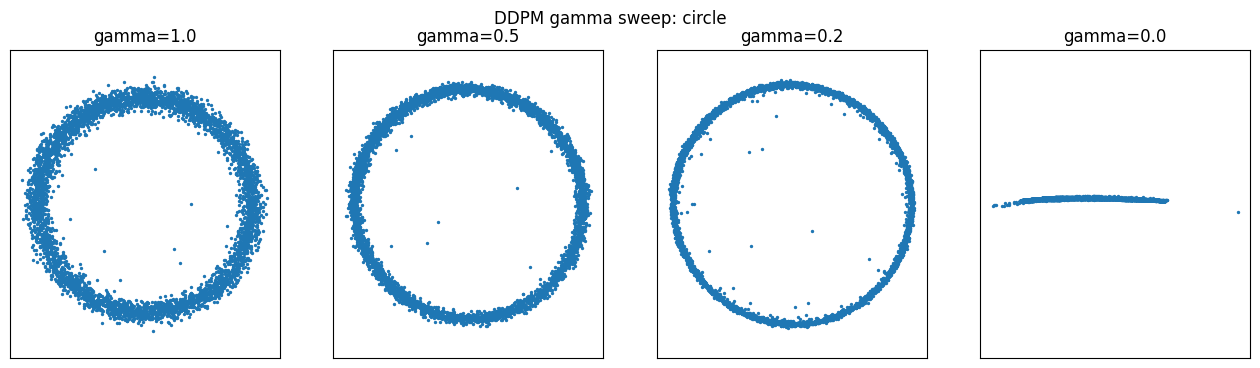

In [36]:
# Circle
fig, axes = plt.subplots(1, len(gammas), figsize=(16, 4))

for ax, g in zip(axes, gammas):
  xg = sample_ddpm_noise_scaled(model, n=5000, gamma=g).detach().cpu()
  ax.scatter(xg[:, 0], xg[:,1], s=2)
  ax.set_title(f"gamma={g}")
  ax.axis("equal")
  ax.set_xticks([])
  ax.set_yticks([])

plt.suptitle("DDPM gamma sweep: circle")
plt.show()

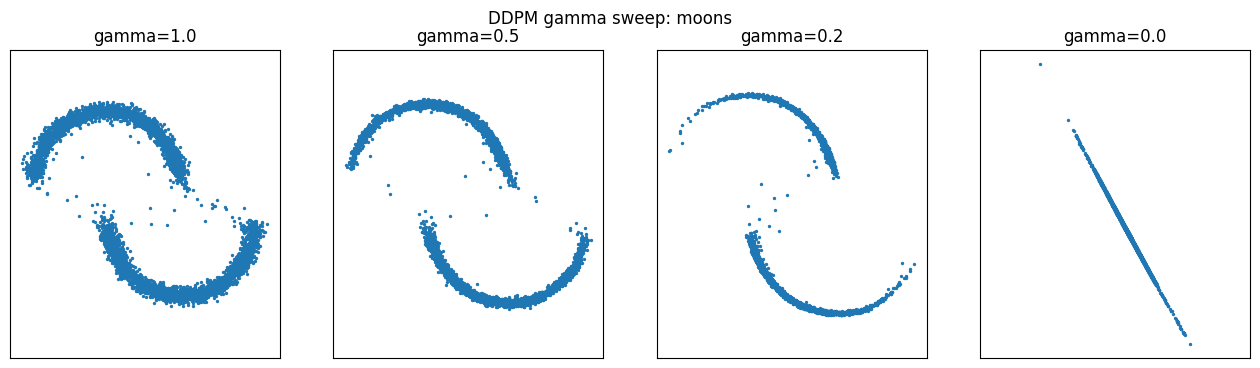

In [37]:
# Moons
fig, axes = plt.subplots(1, len(gammas), figsize=(16, 4))

for ax, g in zip(axes, gammas):
  xg = sample_ddpm_noise_scaled(model2, n=5000, gamma=g).detach().cpu()
  ax.scatter(xg[:, 0], xg[:,1], s=2)
  ax.set_title(f"gamma={g}")
  ax.axis("equal")
  ax.set_xticks([])
  ax.set_yticks([])

plt.suptitle("DDPM gamma sweep: moons")
plt.show()

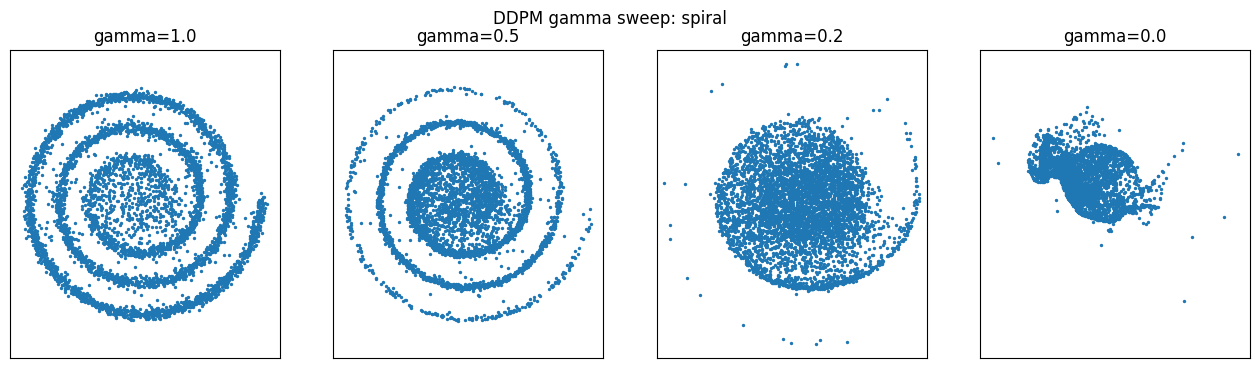

In [38]:
# Spiral
fig, axes = plt.subplots(1, len(gammas), figsize=(16, 4))

for ax, g in zip(axes, gammas):
  xg = sample_ddpm_noise_scaled(model3, n=5000, gamma=g).detach().cpu()
  ax.scatter(xg[:, 0], xg[:,1], s=2)
  ax.set_title(f"gamma={g}")
  ax.axis("equal")
  ax.set_xticks([])
  ax.set_yticks([])

plt.suptitle("DDPM gamma sweep: spiral")
plt.show()

# REFERENCES

[1] Denoising Diffusion Probabilistic Models - Ho et al.  
[2] Improved Denoising Diffusion Probabilistic Models - Alex Nichol and Prafulla Dhariwal  
[3] Attention Is All You Need - Vaswani et al.  
[4] Denoising Diffusion Implicit Models - Song et al.

ChatGPT 5.2 Thinking, Claude Opus 4.6

# CHATGPT SCRIPT TO CREATE THE GIFs

In [ ]:
import math, io
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import torch

# ---- DDPM per-step (uses your already-defined tensors betas, alpha_bar, posterior_var) ----
@torch.no_grad()
def ddpm_step(model, x_t, t_int, betas, alpha_bar, posterior_var, gamma=1.0):
    """
    One DDPM reverse step: x_{t-1} <- x_t
    """
    n = x_t.shape[0]
    device = x_t.device

    t_batch = torch.full((n,), t_int, device=device, dtype=torch.long)
    eps_hat = model(x_t, t_batch)  # (n,2)

    beta_t = betas[t_batch].unsqueeze(1)                 # (n,1)
    alpha_t = (1.0 - betas[t_batch]).unsqueeze(1)        # (n,1)
    abar_t  = alpha_bar[t_batch].unsqueeze(1)            # (n,1)

    mu = (x_t - (beta_t / torch.sqrt(1.0 - abar_t)) * eps_hat) / torch.sqrt(alpha_t)

    if t_int == 0:
        return mu

    z = torch.randn_like(x_t)
    sigma = gamma * torch.sqrt(posterior_var[t_batch].unsqueeze(1))
    return mu + sigma * z


@torch.no_grad()
def make_forward_states_closed_form(x0, alpha_bar, capture_ts):
    """
    Forward noising frames using x_t = sqrt(abar_t)x0 + sqrt(1-abar_t) eps,
    with a fixed eps so it's a coherent "movie".
    """
    device = x0.device
    n = x0.shape[0]
    eps = torch.randn_like(x0)
    frames = []

    for t_int in capture_ts:
        t_batch = torch.full((n,), t_int, device=device, dtype=torch.long)
        abar_t = alpha_bar[t_batch].unsqueeze(1)  # (n,1)
        xt = torch.sqrt(abar_t) * x0 + torch.sqrt(1.0 - abar_t) * eps
        frames.append(xt.detach().cpu().numpy())

    return frames


@torch.no_grad()
def make_reverse_states_ddpm(model, n, T, betas, alpha_bar, posterior_var, capture_ts_rev, gamma=1.0, device="cuda"):
    """
    Reverse denoising frames by running the full DDPM chain for all T steps,
    but only saving frames at specified timesteps.
    """
    model.eval()
    x = torch.randn(n, 2, device=device)
    capture_set = set(capture_ts_rev)
    saved = {}

    for t_int in reversed(range(T)):
        if t_int in capture_set:
            saved[t_int] = x.detach().cpu().numpy()
        x = ddpm_step(model, x, t_int, betas, alpha_bar, posterior_var, gamma=gamma)

    # Return in the same order as capture_ts_rev
    return [saved[t] for t in capture_ts_rev]


def make_forward_reverse_gif_full(
    dataset_name,
    model,
    sampler_fn,
    out_path="diffusion_full.gif",
    n_points=5000,
    stride=10,
    fps=12,
    data_noise=0.05,
    t_max=8*math.pi,
    gamma=1.0,
    lim=None,
):
    """
    Full DDPM reverse trajectory (all timesteps), render every `stride` steps.
    Side-by-side GIF: forward (left) + reverse (right).
    """
    # --- sample x0 (data) ---
    if dataset_name == "spiral":
        x0 = sampler_fn(n_points, noise=data_noise, device=device, t_max=t_max)
    else:
        x0 = sampler_fn(n_points, noise=data_noise, device=device)

    # axis limits
    x0_np = x0.detach().cpu().numpy()
    if lim is None:
        lim = float(np.max(np.abs(x0_np)) * 1.4 + 0.2)

    # --- timesteps to capture ---
    capture_ts_fwd = list(range(0, T, stride))
    if capture_ts_fwd[-1] != T-1:
        capture_ts_fwd.append(T-1)

    capture_ts_rev = list(range(T-1, -1, -stride))
    if capture_ts_rev[-1] != 0:
        capture_ts_rev.append(0)

    # Make lengths match for side-by-side
    K = min(len(capture_ts_fwd), len(capture_ts_rev))
    capture_ts_fwd = capture_ts_fwd[:K]
    capture_ts_rev = capture_ts_rev[:K]

    # --- collect frames data ---
    fwd_states = make_forward_states_closed_form(x0, alpha_bar, capture_ts_fwd)
    rev_states = make_reverse_states_ddpm(model, n_points, T, betas, alpha_bar, posterior_var, capture_ts_rev, gamma=gamma, device=device)

    # --- render frames ---
    frames = []
    for i in range(K):
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))

        axes[0].scatter(fwd_states[i][:,0], fwd_states[i][:,1], s=2)
        axes[0].set_title(f"Forward: t={capture_ts_fwd[i]}")
        axes[0].set_xlim(-lim, lim); axes[0].set_ylim(-lim, lim)
        axes[0].set_aspect("equal"); axes[0].set_xticks([]); axes[0].set_yticks([])

        axes[1].scatter(rev_states[i][:,0], rev_states[i][:,1], s=2)
        axes[1].set_title(f"Reverse DDPM: t={capture_ts_rev[i]}")
        axes[1].set_xlim(-lim, lim); axes[1].set_ylim(-lim, lim)
        axes[1].set_aspect("equal"); axes[1].set_xticks([]); axes[1].set_yticks([])

        plt.tight_layout()

        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
        buf.seek(0)
        frames.append(imageio.imread(buf))
        plt.close(fig)
        buf.close()

    imageio.mimsave(out_path, frames, fps=fps)
    print(f"Saved GIF to: {out_path}")


# ---------- Example usage ----------
samplers = {"circles": sample_circle, "moons": sample_moons, "spiral": sample_spiral}

# circles
make_forward_reverse_gif_full(
    dataset_name="circles",
    model=model,
    sampler_fn=samplers["circles"],
    out_path="circles_full_stride10.gif",
    stride=10,     # render every 10 timesteps -> ~100 frames
    fps=12,
    data_noise=0.05,
    gamma=1.0
)

# moons
make_forward_reverse_gif_full(
    dataset_name="moons",
    model=model2,
    sampler_fn=samplers["moons"],
    out_path="moons_full_stride10.gif",
    stride=10,
    fps=12,
    data_noise=0.05,
    gamma=1.0
)

# spiral (match your training params!)
make_forward_reverse_gif_full(
    dataset_name="spiral",
    model=model3,
    sampler_fn=samplers["spiral"],
    out_path="spiral_full_stride10.gif",
    stride=10,
    fps=12,
    data_noise=0.02,
    t_max=8*math.pi,
    gamma=1.0
)

Saved GIF to: circles_full_stride10.gif
Saved GIF to: moons_full_stride10.gif
Saved GIF to: spiral_full_stride10.gif
